# **Fundación YPF - Formación en Ciencia de Datos**
## **Programa EnergIA Digital**
### **Docente:** Gabriel Acosta
### **Tutora:** Belén Laresca
---
# **PROYECTO FINAL INTEGRADOR: SEGURIDAD VIAL EN CABA**
## **2ª Pre-Entrega: Exploración, Limpieza, Integración y Análisis Exploratorio de Datos (AED)**
**Fecha de entrega:** 25 de Septiembre

> **Integrantes del Grupo 8:**
> - Diego Bianqui
> - Luida Medina
> - Matias Lorenzo

---
### **Tema Seleccionado:**
*Análisis Integral y Caracterización de la Siniestralidad Vial y Víctimas en la Ciudad Autónoma de Buenos Aires (2019 - 2025)*

### **Datasets Oficiales Utilizados:**
- `siniestros_viales_hechos.csv`: Registro oficial de siniestros viales con víctimas (65.818 observaciones, 21 variables).
- `siniestros_viales_victimas.csv`: Registro detallado de personas afectadas por los siniestros (75.197 observaciones, 9 variables).
- **Fuente Oficial:** *Observatorio de Movilidad y Seguridad Vial (OMSV)*, Secretaría de Transporte, Ministerio de Infraestructura y Movilidad, GCBA.


## **1. Introducción, Justificación y Storytelling del Proyecto**

### **1.1. Contexto y Problemática Urbana**
Los siniestros viales constituyen una de las principales causas de morbilidad y mortalidad prevenible en las grandes urbes. En la **Ciudad Autónoma de Buenos Aires (CABA)**, conviven diariamente más de 3 millones de residentes con un flujo flotante superior a 1.5 millones de personas y vehículos procedentes del Área Metropolitana de Buenos Aires (AMBA). Esta interacción masiva genera complejas dinámicas de riesgo vial, sobrecarga los sistemas de emergencia hospitalaria (SAME / Hospitales de Agudos) e impacta en la planificación urbana y de seguridad.

El **Observatorio de Movilidad y Seguridad Vial (OMSV)** recopila y valida sistemáticamente los hechos que involucran víctimas (lesiones culposas según Art. 94/94 bis del CPN y homicidios culposos según Art. 84/84 bis del CPN). Esta base unifica partes policiales de la Policía de la Ciudad con auditorías presenciales en los **14 hospitales de agudos** y un seguimiento judicial de fallecimientos hasta **30 días posteriores** al hecho.

---

### **1.2. Preguntas Guía de Investigación y Negocio**
1. **Dinámica Temporal:** ¿Cómo evolucionó la siniestralidad entre 2019 y 2025? ¿Qué impacto tuvieron las restricciones por la pandemia (2020) y cómo se reconfiguró el tráfico posterior? ¿En qué franjas horarias y días se concentran los siniestros graves?
2. **Distribución Territorial e Infraestructura:** ¿Cuáles son las comunas y tipos de vías (avenidas vs. calles vs. autopistas / Gral. Paz) con mayor densidad de colisiones y mayor tasa de letalidad?
3. **Vulnerabilidad de Actores Viales:** ¿Qué actores viales sufren las consecuencias más severas (motociclistas, peatones, ciclistas) y cuáles son las combinaciones de impacto más frecuentes?
4. **Perfil Sociodemográfico:** ¿Cuál es la pirámide etaria y de género de las víctimas según el rol desempeñado en la vía pública?
5. **Modelado Predictivo (Pre-entrega 3):** ¿Es factible anticipar la gravedad de un siniestro a partir de sus condiciones contextuales iniciales evitando el sesgo de *data leakage*?
6. **Segmentación y Perfiles de Riesgo (Pre-entrega 4):** ¿Podemos identificar agrupamientos naturales (clusters) de accidentes para optimizar la asignación preventiva de patrullajes, señalética y recursos del SAME?

---

### **1.3. Estructura de esta 2ª Pre-Entrega**
- **Sección 2:** Configuración del Entorno y Carga de Datos Oficiales.
- **Sección 3:** Inspección Estructural y Diagnóstico de Calidad de Datos.
- **Sección 4:** Limpieza, Estandarización y Tratamiento de Missing Values / Centinelas.
- **Sección 5:** Ingeniería de Características (Feature Engineering Temporal, Espacial y Vehicular).
- **Sección 6:** Integración Relacional (Data Wrangling Siniestros + Víctimas).
- **Sección 7:** Análisis Exploratorio de Datos (AED Univariado, Bivariado y Multivariado con Storytelling).
- **Sección 8:** Formulación Metodológica y Hoja de Ruta para Modelos Supervisados y Clustering.
- **Sección 9:** Conclusiones y Resumen Ejecutivo.


In [1]:
# Importación de librerías esenciales para Data Science
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de advertencias y visualizaciones
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Estilo profesional de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.titlesize'] = 15

print("Entorno configurado correctamente.")
print(f"Pandas versión: {pd.__version__}")
print(f"Numpy versión: {np.__version__}")
print(f"Seaborn versión: {sns.__version__}")

Entorno configurado correctamente.
Pandas versión: 2.2.3
Numpy versión: 2.1.3
Seaborn versión: 0.13.2


## **2. Carga de los Datasets Oficiales**
Cargamos ambos archivos delimitados por punto y coma (`;`), correspondientes a las tablas de **Hechos** y **Víctimas**.


In [2]:
# Rutas a los datasets
path_hechos = 'siniestros_viales_hechos.csv'
path_victimas = 'siniestros_viales_victimas.csv'

# Fallback si se ejecuta desde el directorio padre
if not os.path.exists(path_hechos):
    path_hechos = 'TP-grupal/siniestros_viales_hechos.csv'
    path_victimas = 'TP-grupal/siniestros_viales_victimas.csv'

# Carga de datos con separador punto y coma
df_hechos_raw = pd.read_csv(path_hechos, sep=';', low_memory=False)
df_victimas_raw = pd.read_csv(path_victimas, sep=';', low_memory=False)

print(f"Dimensiones iniciales df_hechos_raw:   {df_hechos_raw.shape[0]:,} filas × {df_hechos_raw.shape[1]} columnas")
print(f"Dimensiones iniciales df_victimas_raw: {df_victimas_raw.shape[0]:,} filas × {df_victimas_raw.shape[1]} columnas")


Dimensiones iniciales df_hechos_raw:   65,818 filas × 21 columnas
Dimensiones iniciales df_victimas_raw: 75,197 filas × 9 columnas


## **3. Inspección Estructural y Diagnóstico de Calidad de Datos**

### **3.1. Inspección de `df_hechos`**


In [3]:
# Visualización de las primeras 5 filas de Hechos
df_hechos_raw.head()


,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,rango_horario,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro
0,LC-2019-0000053,1,1,0,0,2019-01-01,2019,1,1,01:55:00,1,NaN,Comuna 8,AUTOPISTA,POINT (101813.84712503915943671 95578.55507230...,-58.44351,-34.669125,AUTO-UTILITARIO,AUTO,UTILITARIO,LEVE
1,LC-2019-0000647,1,0,1,0,2019-01-01,2019,1,1,18:50:00,18,DE LOS CONSTITUYENTES AV. y HABANA,Comuna 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,MOTO,AUTO,GRAVE
2,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,13,NaN,Comuna 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE
3,LC-2019-0000194,1,1,0,0,2019-01-01,2019,1,1,07:15:00,7,NaN,Comuna 9,NaN,POINT (94030.76669932194636203 97681.071761248...,-58.528413,-34.650156,AUTO-CAMION,AUTO,CAMION,LEVE
4,LC-2019-0000329,1,1,0,0,2019-01-01,2019,1,1,12:24:00,12,NaN,Comuna 4,NaN,POINT (105367.86665769023238681 97877.75085908...,-58.404748,-34.648387,AUTO-MOVIL,AUTO,MOVIL,LEVE


In [ ]:
# Información general, tipos de datos inferidos y recuento de no nulos
df_hechos_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 65818 entries, 0 to 65817
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   id_siniestro                      65818 non-null  str  
 1   numero_total_de_victimas          65818 non-null  str  
 2   numero_victimas_leve_siniestro    65818 non-null  int64
 3   numero_victimas_grave_siniestro   65818 non-null  int64
 4   numero_victimas_mortal_siniestro  65818 non-null  int64
 5   fecha_siniestro                   65818 non-null  str  
 6   anio_siniestro                    65818 non-null  int64
 7   mes_siniestro                     65818 non-null  int64
 8   dia_siniestro                     65818 non-null  int64
 9   hora_siniestro                    65741 non-null  str  
 10  rango_horario                     65741 non-null  str  
 11  direccion_normalizada_siniestro   52918 non-null  str  
 12  comuna_siniestro                  62801 non

In [ ]:
# Resumen estadístico univariado de variables numéricas en Hechos
df_hechos_raw.describe()


,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,anio_siniestro,mes_siniestro,dia_siniestro
count,65818.000,65818.000,65818.000,65818.000,65818.000,65818.000
mean,1.083,0.048,0.011,2022.242,6.739,15.609
std,0.578,0.233,0.105,2.054,3.419,8.746
min,0.000,0.000,0.000,2019.000,1.000,1.000
25%,1.000,0.000,0.000,2021.000,4.000,8.000
50%,1.000,0.000,0.000,2022.000,7.000,15.000
75%,1.000,0.000,0.000,2024.000,10.000,23.000
max,26.000,10.000,2.000,2025.000,12.000,31.000


### **3.2. Inspección de `df_victimas`**


In [ ]:
# Visualización de las primeras 5 filas de Víctimas
df_victimas_raw.head()


,id_siniestro,fecha_siniestro,anio_siniestro,modo_desplazamiento_victima,sexo_victima,edad_victima,GRAVEdad_victima,rol_victima,fecha_fallecimiento_victima
0,LC-2019-0022650,2019-01-11,2019.000,BICICLETA,F,25,GRAVE,CICLISTA,NaN
1,LC-2019-0068291,2019-02-01,2019.000,BICICLETA,F,16,GRAVE,CICLISTA,NaN
2,LC-2019-0139186,2019-03-06,2019.000,BICICLETA,F,32,GRAVE,CICLISTA,NaN
3,LC-2019-0247839,2019-04-21,2019.000,BICICLETA,F,35,GRAVE,CICLISTA,NaN
4,LC-2019-0283677,2019-05-07,2019.000,BICICLETA,F,42,GRAVE,CICLISTA,NaN


In [ ]:
# Información general y tipos inferidos en Víctimas
df_victimas_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 75197 entries, 0 to 75196
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_siniestro                 75193 non-null  str    
 1   fecha_siniestro              75193 non-null  str    
 2   anio_siniestro               75193 non-null  float64
 3   modo_desplazamiento_victima  75193 non-null  str    
 4   sexo_victima                 75193 non-null  str    
 5   edad_victima                 75193 non-null  str    
 6   GRAVEdad_victima             75193 non-null  str    
 7   rol_victima                  75193 non-null  str    
 8   fecha_fallecimiento_victima  703 non-null    str    
dtypes: float64(1), str(8)
memory usage: 5.2 MB


### **3.3. Diagnóstico de Problemas de Calidad Identificados**
A partir de la inspección inicial, detectamos las siguientes inconsistencias que deben ser subsanadas en el proceso de limpieza:
1. **Valores centinela de texto:** Presencia de valores como `'SD'`, `'sd'`, `'Sin datos'`, `'#¡REF!'` que representan datos faltantes pero están codificados como strings, impidiendo la correcta conversión de tipos en columnas como `edad_victima`, `longitud_siniestro`, `latitud_siniestro` y `numero_total_de_victimas`.
2. **Inconsistencias en nombres de columnas y categorías:** La columna `'GRAVEdad_victima'` presenta mayúsculas mezcladas; los valores de gravedad en víctimas contienen tanto `'MORTAL'` como `'mortal'`; los roles contienen `'CONDUCTOR'`, `'conductor'` y `'Conductor'`.
3. **Filas completamente nulas:** En `df_victimas` existen 4 filas finales totalmente vacías.
4. **Tipos de datos incorrectos:** Fechas en formato string que deben convertirse a `datetime`; variables temporales y de coordenadas que requieren parseo numérico.
5. **Integridad referencial:** Verificación de unicidad y correspondencia entre los identificadores `id_siniestro` de ambas tablas.


In [ ]:
# Verificación de integridad referencial entre ambas tablas
unique_hechos_ids = set(df_hechos_raw['id_siniestro'].dropna())
unique_victimas_ids = set(df_victimas_raw['id_siniestro'].dropna())

print(f"Total IDs únicos en Hechos:   {len(unique_hechos_ids):,}")
print(f"Total IDs únicos en Víctimas: {len(unique_victimas_ids):,}")
print(f"IDs en Hechos que están en Víctimas: {len(unique_hechos_ids.intersection(unique_victimas_ids)):,} (100.0%)")
print(f"IDs huérfanos en Víctimas: {len(unique_victimas_ids - unique_hechos_ids)}")


Total IDs únicos en Hechos:   65,818
Total IDs únicos en Víctimas: 65,818
IDs en Hechos que están en Víctimas: 65,818 (100.0%)
IDs huérfanos en Víctimas: 0


## **4. Limpieza y Estandarización de Datos (Data Cleaning)**


In [ ]:
# 1. Limpieza de df_victimas
df_victimas = df_victimas_raw.dropna(how='all').copy()

# Normalizar nombre de columna gravedad
df_victimas.rename(columns={'GRAVEdad_victima': 'gravedad_victima'}, inplace=True)

# Normalizar cadenas de texto a mayúsculas y sin espacios
text_cols_victimas = ['modo_desplazamiento_victima', 'sexo_victima', 'gravedad_victima', 'rol_victima']
for col in text_cols_victimas:
    df_victimas[col] = df_victimas[col].astype(str).str.strip().str.upper()

# Reemplazar valores centinela por NaN / SD unificado
df_victimas['gravedad_victima'] = df_victimas['gravedad_victima'].replace(['SD', 'NAN'], np.nan)
df_victimas['sexo_victima'] = df_victimas['sexo_victima'].replace(['SD', 'NAN'], 'SD')
df_victimas['rol_victima'] = df_victimas['rol_victima'].replace(['SD', 'NAN'], 'SD')

# Conversión de edad a numérica (los 'SD' se convierten a NaN)
df_victimas['edad_victima'] = pd.to_numeric(df_victimas['edad_victima'].replace(['SD', 'sd'], np.nan), errors='coerce')

# Conversión de fechas
df_victimas['fecha_siniestro_dt'] = pd.to_datetime(df_victimas['fecha_siniestro'], errors='coerce')
df_victimas['fecha_fallecimiento_dt'] = pd.to_datetime(df_victimas['fecha_fallecimiento_victima'], errors='coerce')

print("✅ df_victimas limpiado exitosamente.")
print(df_victimas.info())


✅ df_victimas limpiado exitosamente.
<class 'pandas.DataFrame'>
RangeIndex: 75193 entries, 0 to 75192
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   id_siniestro                 75193 non-null  str           
 1   fecha_siniestro              75193 non-null  str           
 2   anio_siniestro               75193 non-null  float64       
 3   modo_desplazamiento_victima  75193 non-null  str           
 4   sexo_victima                 75193 non-null  str           
 5   edad_victima                 51821 non-null  float64       
 6   gravedad_victima             75193 non-null  str           
 7   rol_victima                  75193 non-null  str           
 8   fecha_fallecimiento_victima  703 non-null    str           
 9   fecha_siniestro_dt           75193 non-null  datetime64[us]
 10  fecha_fallecimiento_dt       703 non-null    datetime64[us]
dtypes: datetime64[u

In [ ]:
# 2. Limpieza de df_hechos
df_hechos = df_hechos_raw.dropna(how='all').copy()

# Normalizar gravedad
df_hechos['gravedad_siniestro'] = df_hechos['gravedad_siniestro'].astype(str).str.strip().str.upper()

# Reconstruir numero_total_de_victimas en caso de que figure como 'SD'
# Observamos en el diagnóstico que cuando es 'SD', la suma de leve+grave+mortal da exactamente el valor real
suma_victimas = (df_hechos['numero_victimas_leve_siniestro'].fillna(0) +
                 df_hechos['numero_victimas_grave_siniestro'].fillna(0) +
                 df_hechos['numero_victimas_mortal_siniestro'].fillna(0))

df_hechos['numero_total_de_victimas'] = pd.to_numeric(
    df_hechos['numero_total_de_victimas'].replace(['SD', 'sd'], np.nan),
    errors='coerce'
).fillna(suma_victimas).astype(int)

# Normalizar columnas de texto
text_cols_hechos = ['comuna_siniestro', 'tipo_de_via_siniestro', 'participantes_siniestro',
                     'modo_desplazamiento_victima', 'contraparte_siniestro']
for col in text_cols_hechos:
    df_hechos[col] = df_hechos[col].astype(str).str.strip().str.upper()
    df_hechos[col] = df_hechos[col].replace(['SD', 'NAN', 'NONE'], 'SD')

# Parseo de coordenadas geográficas
df_hechos['longitud_siniestro_num'] = pd.to_numeric(
    df_hechos['longitud_siniestro'].astype(str).str.replace(',', '.').replace(['SD', 'sd', '#¡REF!'], np.nan),
    errors='coerce'
)
df_hechos['latitud_siniestro_num'] = pd.to_numeric(
    df_hechos['latitud_siniestro'].astype(str).str.replace(',', '.').replace(['SD', 'sd', '#¡REF!'], np.nan),
    errors='coerce'
)

# Parseo de fechas
df_hechos['fecha_siniestro_dt'] = pd.to_datetime(df_hechos['fecha_siniestro'], errors='coerce')

print("df_hechos limpiado exitosamente.")
print(f"Siniestros procesados: {len(df_hechos):,}")


df_hechos limpiado exitosamente.
Siniestros procesados: 65,818


## **5. Ingeniería de Características (Feature Engineering)**
En esta etapa construimos variables enriquecidas a partir de los datos crudos, indispensables tanto para el AED como para los futuros modelos predictivos y de clustering.

### **5.1. Variables Temporales**
- `hora_num`: Hora del evento extraída numéricamente (0 a 23).
- `franja_horaria`: Madrugada (00-06), Mañana (06-12), Tarde (12-18), Noche (18-24).
- `dia_semana_nombre`: Nombre del día de la semana (Lunes a Domingo).
- `es_fin_de_semana`: Variable binaria (1 si es Sábado o Domingo, 0 en caso contrario).
- `es_hora_pico`: Variable binaria (1 si ocurre en días hábiles entre 07-10 hs o 17-20 hs).
- `estacion_anio`: Estación climática para el hemisferio sur (Verano, Otoño, Invierno, Primavera).


In [ ]:
# Extracción de la hora numérica
df_hechos['hora_num'] = pd.to_numeric(
    df_hechos['hora_siniestro'].astype(str).str.split(':').str[0],
    errors='coerce'
)

# Creación de Franjas Horarias
def categorizar_franja_horaria(hora):
    if pd.isna(hora):
        return 'SD'
    if 0 <= hora < 6:
        return 'Madrugada (00-06hs)'
    elif 6 <= hora < 12:
        return 'Mañana (06-12hs)'
    elif 12 <= hora < 18:
        return 'Tarde (12-18hs)'
    else:
        return 'Noche (18-24hs)'

df_hechos['franja_horaria'] = df_hechos['hora_num'].apply(categorizar_franja_horaria)

# Día de la semana y fin de semana
dias_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
df_hechos['dia_semana_num'] = df_hechos['fecha_siniestro_dt'].dt.dayofweek
df_hechos['dia_semana_nombre'] = df_hechos['dia_semana_num'].map(dias_map)
df_hechos['es_fin_de_semana'] = df_hechos['dia_semana_num'].isin([5, 6]).astype(int)

# Hora pico laboral vectorizada (Lun-Vie de 7 a 10 y de 17 a 20)
es_laboral = df_hechos['es_fin_de_semana'] == 0
hora = df_hechos['hora_num']
pico_manana = (hora >= 7) & (hora <= 10)
pico_tarde = (hora >= 17) & (hora <= 20)
df_hechos['es_hora_pico'] = (es_laboral & (pico_manana | pico_tarde)).astype(int)

# Estación del año (Hemisferio Sur)
def categorizar_estacion(mes):
    if mes in [12, 1, 2]:
        return 'Verano'
    elif mes in [3, 4, 5]:
        return 'Otoño'
    elif mes in [6, 7, 8]:
        return 'Invierno'
    else:
        return 'Primavera'

df_hechos['estacion_anio'] = df_hechos['mes_siniestro'].apply(categorizar_estacion)

print("Variables temporales generadas:")
print(df_hechos[['fecha_siniestro', 'dia_semana_nombre', 'franja_horaria', 'es_fin_de_semana', 'es_hora_pico', 'estacion_anio']].head(3))


Variables temporales generadas:
  fecha_siniestro dia_semana_nombre       franja_horaria  es_fin_de_semana  \
0      2019-01-01            Martes  Madrugada (00-06hs)                 0   
1      2019-01-01            Martes      Noche (18-24hs)                 0   
2      2019-01-01            Martes      Tarde (12-18hs)                 0   

   es_hora_pico estacion_anio  
0             0        Verano  
1             1        Verano  
2             0        Verano  


### **5.2. Variables Espaciales y de Dinámica Vehicular**
- `comuna_num`: Número entero de la comuna (1 a 15).
- `zona_caba`: Agrupamiento macro-territorial (Norte, Centro, Sur, Oeste).
- `tipo_via_normalizado`: Normalización de arterias (Avenida, Calle, Autopista, Av. Gral Paz, Otros).
- Variables dummies de involucramiento vehicular: `involucra_moto`, `involucra_peaton`, `involucra_bicicleta`, `involucra_transporte_publico`, `involucra_auto` e `involucra_pesado`.


In [ ]:
# Extracción de Comuna Numérica
df_hechos['comuna_num'] = df_hechos['comuna_siniestro'].str.extract(r'(\d+)').astype(float)

# Agrupación Macro-Territorial de CABA
def asignar_zona_caba(comuna):
    if pd.isna(comuna):
        return 'SD'
    comuna = int(comuna)
    if comuna in [2, 12, 13, 14]:
        return 'Zona Norte'
    elif comuna in [1, 3, 5, 6, 7, 15]:
        return 'Zona Centro'
    elif comuna in [4, 8, 9]:
        return 'Zona Sur'
    elif comuna in [10, 11]:
        return 'Zona Oeste'
    return 'SD'

df_hechos['zona_caba'] = df_hechos['comuna_num'].apply(asignar_zona_caba)

# Normalización del Tipo de Vía
def normalizar_tipo_via(via):
    via_str = str(via).upper().strip()
    if 'AVENIDA' in via_str or 'AV.' in via_str:
        if 'GRAL. PAZ' in via_str or 'GENERAL PAZ' in via_str:
            return 'Av. Gral. Paz'
        return 'Avenida'
    elif 'AUTOPISTA' in via_str or 'AU' in via_str:
        return 'Autopista'
    elif 'CALLE' in via_str:
        return 'Calle'
    elif 'GRAL' in via_str or 'PAZ' in via_str:
        return 'Av. Gral. Paz'
    elif via_str == 'SD' or pd.isna(via):
        return 'Sin Datos'
    else:
        return 'Otra'

df_hechos['tipo_via_normalizado'] = df_hechos['tipo_de_via_siniestro'].apply(normalizar_tipo_via)

# Variables de Involucramiento Vehicular (Features Binarias)
participantes_total = df_hechos['participantes_siniestro'].astype(str) + " " + df_hechos['modo_desplazamiento_victima'].astype(str) + " " + df_hechos['contraparte_siniestro'].astype(str)

df_hechos['involucra_moto'] = participantes_total.str.contains('MOTO').astype(int)
df_hechos['involucra_peaton'] = participantes_total.str.contains('PEATON').astype(int)
df_hechos['involucra_bicicleta'] = participantes_total.str.contains('BICICLETA|CICLISTA').astype(int)
df_hechos['involucra_transporte_publico'] = participantes_total.str.contains('TRANSPORTE PUBLICO|PASAJEROS|COLECTIVO').astype(int)
df_hechos['involucra_auto'] = participantes_total.str.contains('AUTO|TAXI').astype(int)
df_hechos['involucra_pesado'] = participantes_total.str.contains('CAMION|UTILITARIO|CARGA').astype(int)

print("Variables espaciales y vehiculares generadas:")
print(df_hechos[['comuna_siniestro', 'zona_caba', 'tipo_via_normalizado', 'involucra_moto', 'involucra_peaton']].head(3))


Variables espaciales y vehiculares generadas:
  comuna_siniestro   zona_caba tipo_via_normalizado  involucra_moto  \
0         COMUNA 8    Zona Sur            Autopista               0   
1        COMUNA 12  Zona Norte              Avenida               1   
2        COMUNA 11  Zona Oeste            Sin Datos               0   

   involucra_peaton  
0                 0  
1                 0  
2                 0  


## **6. Integración y Data Wrangling (Merge Hechos + Víctimas)**
Para responder a la problemática de manera integral, precalculamos columnas indicadoras en `Víctimas` y agrupamos por cada `id_siniestro` para obtener métricas agregadas vectorizadas y consolidar nuestro **Dataset Analítico Unificado** (`df_analitico`).


In [ ]:
# Precalcular indicadores en víctimas de forma vectorizada
df_victimas['es_hombre'] = (df_victimas['sexo_victima'] == 'M').astype(int)
df_victimas['es_mujer'] = (df_victimas['sexo_victima'] == 'F').astype(int)
df_victimas['es_sexo_sd'] = (df_victimas['sexo_victima'] == 'SD').astype(int)
df_victimas['es_peaton'] = (df_victimas['rol_victima'] == 'PEATON').astype(int)
df_victimas['es_ciclista'] = (df_victimas['rol_victima'] == 'CICLISTA').astype(int)
df_victimas['es_conductor'] = (df_victimas['rol_victima'] == 'CONDUCTOR').astype(int)
df_victimas['es_pasajero'] = (df_victimas['rol_victima'] == 'PASAJERO').astype(int)

# Agrupaciones ultra-rápidas a nivel siniestro
victimas_agg = df_victimas.groupby('id_siniestro').agg(
    total_victimas_reales=('id_siniestro', 'count'),
    edad_victima_media=('edad_victima', 'mean'),
    edad_victima_min=('edad_victima', 'min'),
    edad_victima_max=('edad_victima', 'max'),
    victimas_hombres=('es_hombre', 'sum'),
    victimas_mujeres=('es_mujer', 'sum'),
    victimas_sexo_sd=('es_sexo_sd', 'sum'),
    victimas_rol_peaton=('es_peaton', 'sum'),
    victimas_rol_ciclista=('es_ciclista', 'sum'),
    victimas_rol_conductor=('es_conductor', 'sum'),
    victimas_rol_pasajero=('es_pasajero', 'sum')
).reset_index()

# Merge con el dataset de Hechos
df_analitico = pd.merge(df_hechos, victimas_agg, on='id_siniestro', how='left')

print(f"Dataset Analítico Integrado:")
print(f"Filas: {df_analitico.shape[0]:,} | Columnas: {df_analitico.shape[1]}")
df_analitico.head(3)


Dataset Analítico Integrado:
Filas: 65,818 | Columnas: 51


,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,rango_horario,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro,longitud_siniestro_num,latitud_siniestro_num,fecha_siniestro_dt,hora_num,franja_horaria,dia_semana_num,dia_semana_nombre,es_fin_de_semana,es_hora_pico,estacion_anio,comuna_num,zona_caba,tipo_via_normalizado,involucra_moto,involucra_peaton,involucra_bicicleta,involucra_transporte_publico,involucra_auto,involucra_pesado,total_victimas_reales,edad_victima_media,edad_victima_min,edad_victima_max,victimas_hombres,victimas_mujeres,victimas_sexo_sd,victimas_rol_peaton,victimas_rol_ciclista,victimas_rol_conductor,victimas_rol_pasajero
0,LC-2019-0000053,1,1,0,0,2019-01-01,2019,1,1,01:55:00,1,NaN,COMUNA 8,AUTOPISTA,POINT (101813.84712503915943671 95578.55507230...,-58.44351,-34.669125,AUTO-UTILITARIO,AUTO,UTILITARIO,LEVE,-58.444,-34.669,2019-01-01,1.000,Madrugada (00-06hs),1,Martes,0,0,Verano,8.000,Zona Sur,Autopista,0,0,0,0,1,1,1,57.000,57.000,57.000,1,0,0,0,0,0,0
1,LC-2019-0000647,1,0,1,0,2019-01-01,2019,1,1,18:50:00,18,DE LOS CONSTITUYENTES AV. y HABANA,COMUNA 12,AVENIDA,POINT (97510.27137648081406951 105087.83369881...,-58.490436,-34.583403,MOTO-AUTO,MOTO,AUTO,GRAVE,-58.490,-34.583,2019-01-01,18.000,Noche (18-24hs),1,Martes,0,1,Verano,12.000,Zona Norte,Avenida,1,0,0,0,1,0,1,54.000,54.000,54.000,1,0,0,0,0,0,0
2,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,13,NaN,COMUNA 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE,-58.525,-34.603,2019-01-01,13.000,Tarde (12-18hs),1,Martes,0,0,Verano,11.000,Zona Oeste,Sin Datos,0,0,0,0,1,0,3,40.333,37.000,42.000,2,1,0,0,0,0,0


## **7. Análisis Exploratorio de Datos (AED) y Visualizaciones con Storytelling**

---
### **Bloque 1: Dimensión Temporal y Tendencias Históricas**
Analizamos la evolución interanual, la estacionalidad mensual y el patrón horario de los siniestros viales en CABA.


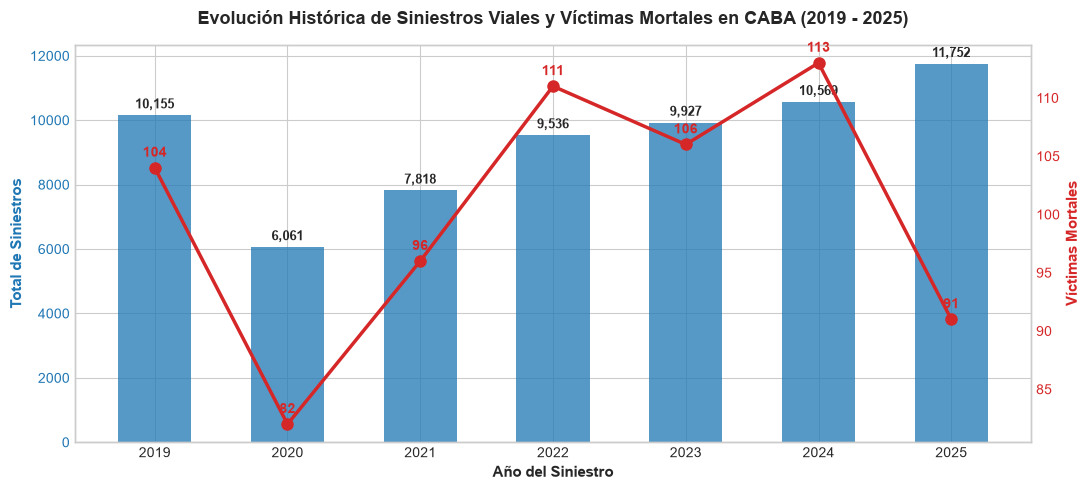

In [ ]:
# 1. Evolución Anual de Siniestros y Víctimas (2019-2025)
anual_stats = df_analitico.groupby('anio_siniestro').agg(
    total_siniestros=('id_siniestro', 'count'),
    total_victimas=('numero_total_de_victimas', 'sum'),
    total_mortales=('numero_victimas_mortal_siniestro', 'sum'),
    total_graves=('numero_victimas_grave_siniestro', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))

color = '#1f77b4'
ax1.set_xlabel('Año del Siniestro', fontweight='bold')
ax1.set_ylabel('Total de Siniestros', color=color, fontweight='bold')
bars = ax1.bar(anual_stats['anio_siniestro'], anual_stats['total_siniestros'], color=color, alpha=0.75, width=0.55, label='Siniestros')
ax1.tick_params(axis='y', labelcolor=color)

# Anotaciones sobre las barras
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# Eje secundario para víctimas mortales
ax2 = ax1.twinx()
color2 = '#d62728'
ax2.set_ylabel('Víctimas Mortales', color=color2, fontweight='bold')
lines = ax2.plot(anual_stats['anio_siniestro'], anual_stats['total_mortales'], color=color2, marker='o', linewidth=2.5, markersize=8, label='Víctimas Mortales')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(False)

for x, y in zip(anual_stats['anio_siniestro'], anual_stats['total_mortales']):
    ax2.annotate(f'{int(y)}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontweight='bold', color=color2)

plt.title('Evolución Histórica de Siniestros Viales y Víctimas Mortales en CABA (2019 - 2025)', pad=15)
plt.tight_layout()
plt.show()


**Hallazgo Clave 1 (Evolución Temporal):**
- En **2020** se observa una caída abrupta del 40% en los siniestros debido a las medidas de Aislamiento Social Preventivo y Obligatorio (ASPO) por la pandemia de COVID-19.
- A partir de 2021, la siniestralidad retoma una trayectoria ascendente continua hasta superar los 11.700 siniestros en 2025. Sin embargo, la cantidad de víctimas mortales se mantiene estabilizada en torno a ~100-110 muertes anuales, indicando una reducción relativa en la letalidad global.


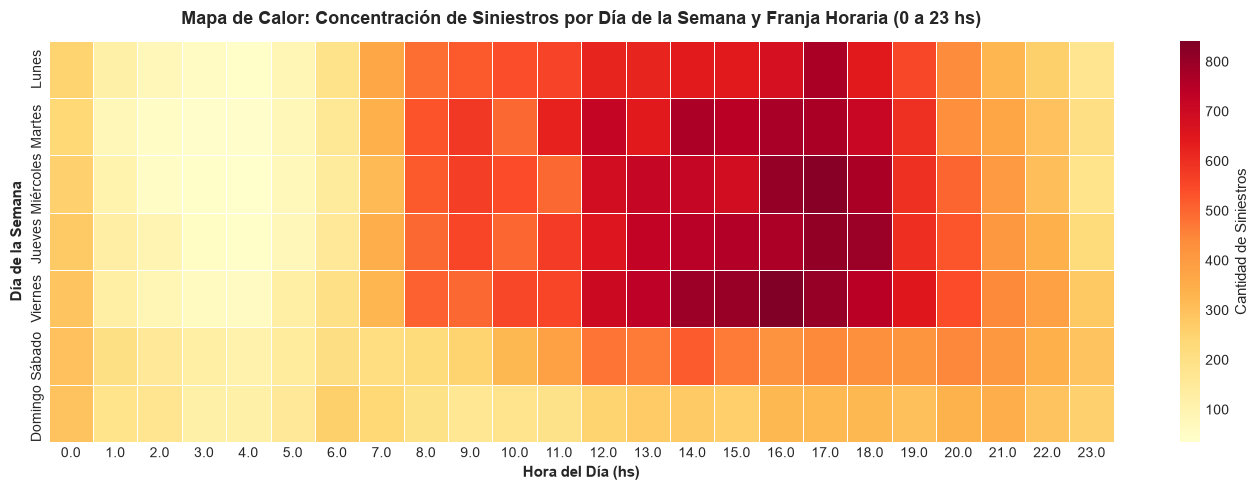

In [ ]:
# 2. Heatmap: Intensidad de Siniestros por Día de la Semana y Hora del Día
dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
heatmap_data = df_analitico.dropna(subset=['hora_num']).pivot_table(
    index='dia_semana_nombre',
    columns='hora_num',
    values='id_siniestro',
    aggfunc='count'
).reindex(dias_orden)

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Cantidad de Siniestros'})
plt.title('Mapa de Calor: Concentración de Siniestros por Día de la Semana y Franja Horaria (0 a 23 hs)', pad=12)
plt.xlabel('Hora del Día (hs)', fontweight='bold')
plt.ylabel('Día de la Semana', fontweight='bold')
plt.tight_layout()
plt.show()


**Hallazgo Clave 2 (Patrón Horario y Semanal):**
- De **Lunes a Viernes**, los siniestros exhiben una estructura bimodal con picos pronunciados en las horas pico laborales: **08:00 a 10:00 hs** (ingreso laboral/escolar) y **17:00 a 19:00 hs** (egreso).
- Los **Sábados y Domingos**, el patrón se desplaza hacia la **madrugada (03:00 a 07:00 hs)** y las horas de la tarde, coincidiendo con actividades recreativas y nocturnas.


---
### **Bloque 2: Dimensión Espacial y de Infraestructura Vial**
Examinamos cómo se distribuyen los incidentes a través de las 15 comunas y en los distintos tipos de arterias viales.


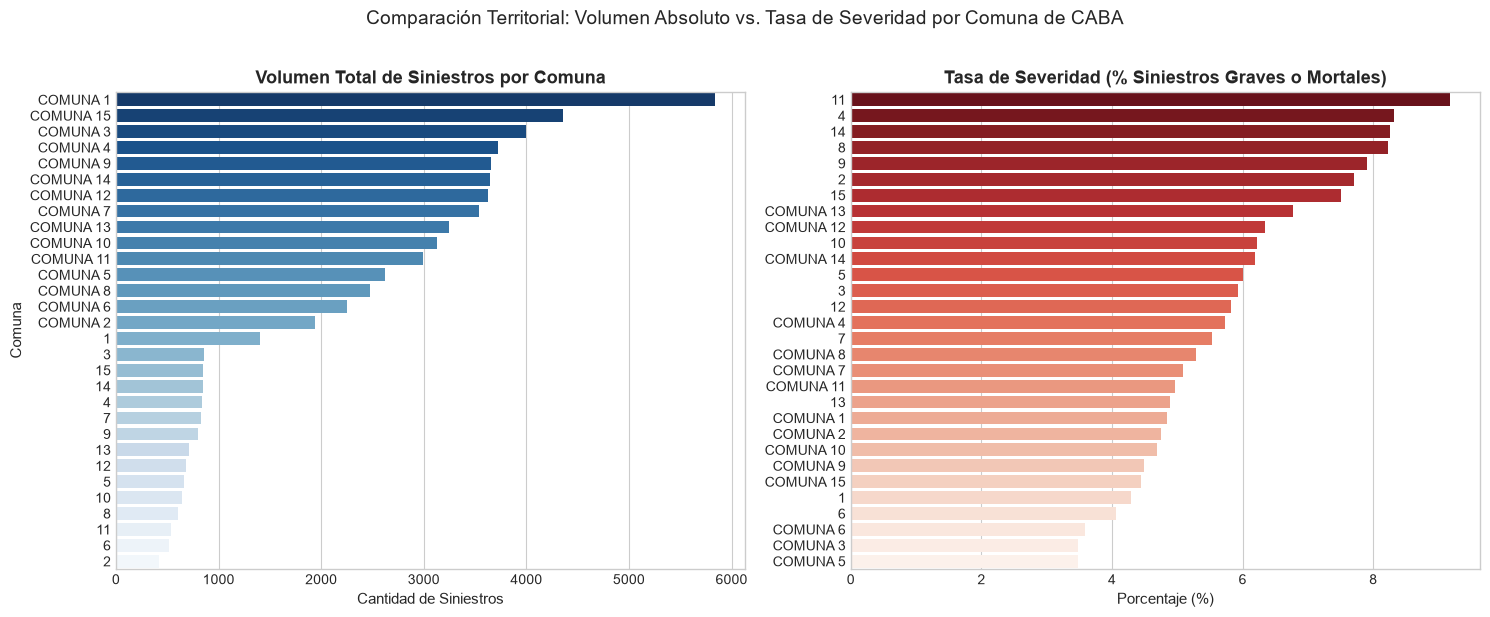

In [ ]:
# 3. Siniestros y Tasa de Gravedad por Comuna
comuna_stats = df_analitico[df_analitico['comuna_siniestro'] != 'SD'].groupby('comuna_siniestro').agg(
    total_siniestros=('id_siniestro', 'count'),
    total_graves=('numero_victimas_grave_siniestro', 'sum'),
    total_mortales=('numero_victimas_mortal_siniestro', 'sum')
).reset_index()

comuna_stats['tasa_grave_mortal_pct'] = (
    (comuna_stats['total_graves'] + comuna_stats['total_mortales']) / comuna_stats['total_siniestros']
) * 100

comuna_stats = comuna_stats.sort_values(by='total_siniestros', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico A: Total de siniestros por comuna
sns.barplot(data=comuna_stats, x='total_siniestros', y='comuna_siniestro', palette='Blues_r', ax=ax1)
ax1.set_title('Volumen Total de Siniestros por Comuna', fontweight='bold')
ax1.set_xlabel('Cantidad de Siniestros')
ax1.set_ylabel('Comuna')

# Gráfico B: Tasa de severidad (% graves + mortales)
sns.barplot(data=comuna_stats.sort_values(by='tasa_grave_mortal_pct', ascending=False),
            x='tasa_grave_mortal_pct', y='comuna_siniestro', palette='Reds_r', ax=ax2)
ax2.set_title('Tasa de Severidad (% Siniestros Graves o Mortales)', fontweight='bold')
ax2.set_xlabel('Porcentaje (%)')
ax2.set_ylabel('')

plt.suptitle('Comparación Territorial: Volumen Absoluto vs. Tasa de Severidad por Comuna de CABA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


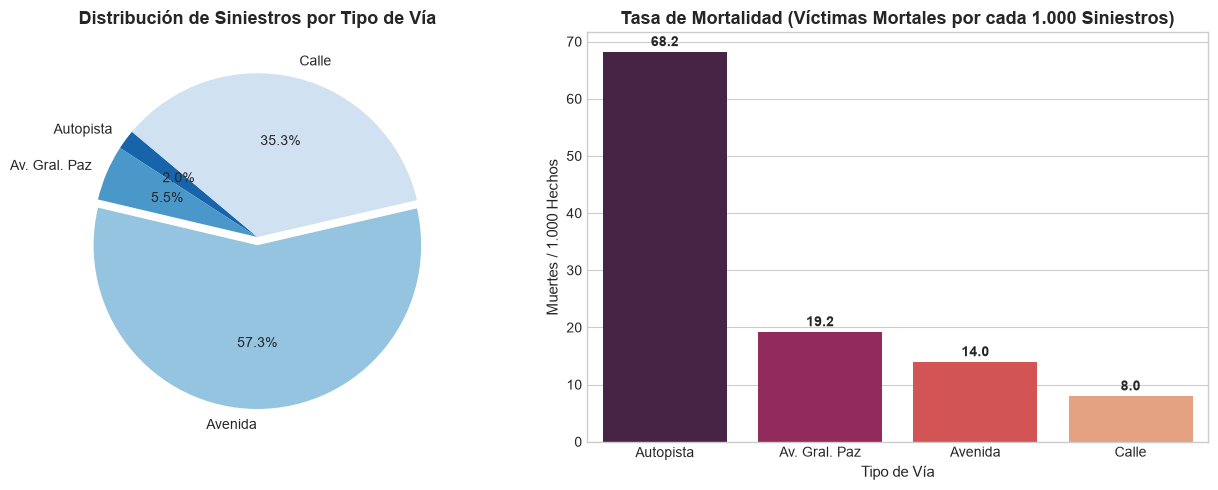

In [ ]:
# 4. Siniestralidad según Tipo de Arteria Vial
via_stats = df_analitico[df_analitico['tipo_via_normalizado'] != 'Sin Datos'].groupby('tipo_via_normalizado').agg(
    total_siniestros=('id_siniestro', 'count'),
    total_mortales=('numero_victimas_mortal_siniestro', 'sum'),
    total_graves=('numero_victimas_grave_siniestro', 'sum')
).reset_index()

via_stats['tasa_mortal_por_mil'] = (via_stats['total_mortales'] / via_stats['total_siniestros']) * 1000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: Siniestros por vía
ax1.pie(via_stats['total_siniestros'], labels=via_stats['tipo_via_normalizado'], autopct='%1.1f%%',
        colors=sns.color_palette('Blues_r', len(via_stats)), startangle=140, explode=[0.05 if v=='Avenida' else 0 for v in via_stats['tipo_via_normalizado']])
ax1.set_title('Distribución de Siniestros por Tipo de Vía', fontweight='bold')

# Gráfico 2: Tasa de Mortalidad por cada 1.000 siniestros
sns.barplot(data=via_stats.sort_values('tasa_mortal_por_mil', ascending=False),
            x='tipo_via_normalizado', y='tasa_mortal_por_mil', palette='rocket', ax=ax2)
ax2.set_title('Tasa de Mortalidad (Víctimas Mortales por cada 1.000 Siniestros)', fontweight='bold')
ax2.set_xlabel('Tipo de Vía')
ax2.set_ylabel('Muertes / 1.000 Hechos')

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()


**Hallazgo Clave 3 (Espacio e Infraestructura):**
- **Comuna 1** (Retiro, San Nicolás, Puerto Madero, San Telmo, Montserrat, Constitución) lidera ampliamente en cantidad absoluta de siniestros debido a la alta densidad de flujo vehicular y peatonal.
- Sin embargo, las comunas del sur y oeste (**Comunas 8, 9 y 4**) registran las **tasas de severidad más elevadas**.
- Las **Avenidas** concentran el **57.4%** del total de choques. No obstante, las vías de alta velocidad (**Autopistas y Av. General Paz**) triplican la tasa de mortalidad respecto a las calles secundarias debido a las velocidades de impacto.


---
### **Bloque 3: Dinámica de Participantes y Vulnerabilidad**
Analizamos qué medios de transporte resultan más vulnerables y cuáles son las combinaciones de impacto más frecuentes.


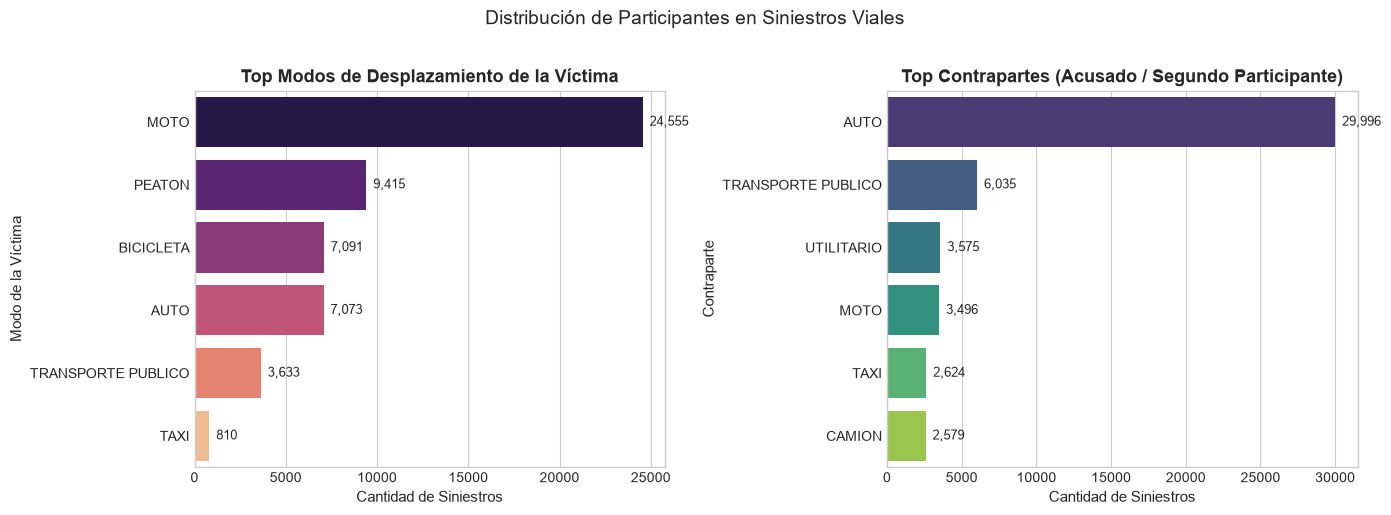

In [ ]:
# 5. Modo de desplazamiento de la víctima y contraparte más frecuente
top_modos = df_analitico[df_analitico['modo_desplazamiento_victima'] != 'SD']['modo_desplazamiento_victima'].value_counts().head(6)
top_contra = df_analitico[df_analitico['contraparte_siniestro'] != 'SD']['contraparte_siniestro'].value_counts().head(6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top_modos.values, y=top_modos.index, palette='magma', ax=ax1)
ax1.set_title('Top Modos de Desplazamiento de la Víctima', fontweight='bold')
ax1.set_xlabel('Cantidad de Siniestros')
ax1.set_ylabel('Modo de la Víctima')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_width()):,}',
                 (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')

sns.barplot(x=top_contra.values, y=top_contra.index, palette='viridis', ax=ax2)
ax2.set_title('Top Contrapartes (Acusado / Segundo Participante)', fontweight='bold')
ax2.set_xlabel('Cantidad de Siniestros')
ax2.set_ylabel('Contraparte')

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_width()):,}',
                 (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')

plt.suptitle('Distribución de Participantes en Siniestros Viales', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


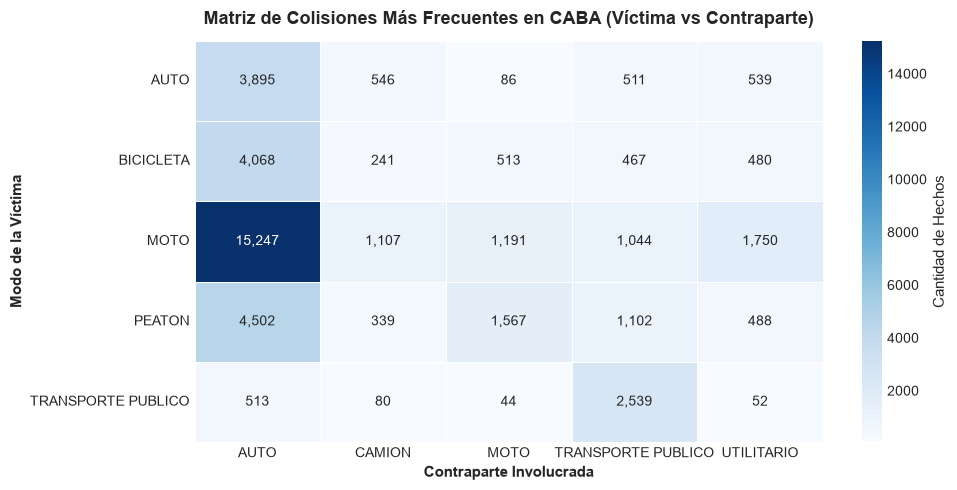

In [ ]:
# 6. Matriz de Co-ocurrencia: Modo Víctima vs Contraparte
top_5_victima = ['MOTO', 'PEATON', 'BICICLETA', 'AUTO', 'TRANSPORTE PUBLICO']
top_5_contra = ['AUTO', 'TRANSPORTE PUBLICO', 'UTILITARIO', 'MOTO', 'CAMION']

matriz_colisiones = df_analitico[
    df_analitico['modo_desplazamiento_victima'].isin(top_5_victima) &
    df_analitico['contraparte_siniestro'].isin(top_5_contra)
].pivot_table(index='modo_desplazamiento_victima', columns='contraparte_siniestro', values='id_siniestro', aggfunc='count', fill_value=0)

plt.figure(figsize=(10, 5))
sns.heatmap(matriz_colisiones, annot=True, fmt=',d', cmap='Blues', linewidths=0.5, cbar_kws={'label': 'Cantidad de Hechos'})
plt.title('Matriz de Colisiones Más Frecuentes en CABA (Víctima vs Contraparte)', pad=12)
plt.xlabel('Contraparte Involucrada', fontweight='bold')
plt.ylabel('Modo de la Víctima', fontweight='bold')
plt.tight_layout()
plt.show()


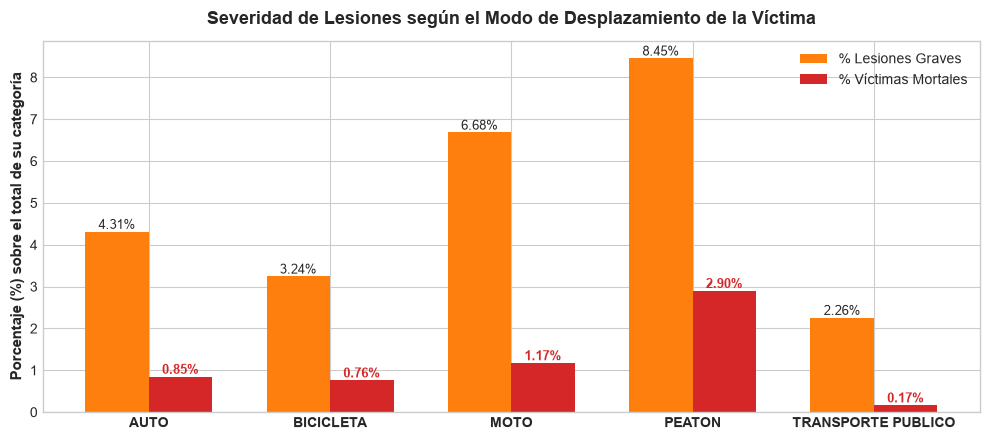

In [ ]:
# 7. Tasa de Letalidad según Modo de Desplazamiento de la Víctima
modo_severidad = df_analitico[df_analitico['modo_desplazamiento_victima'].isin(top_5_victima)].groupby('modo_desplazamiento_victima').agg(
    total=('id_siniestro', 'count'),
    mortales=('numero_victimas_mortal_siniestro', 'sum'),
    graves=('numero_victimas_grave_siniestro', 'sum')
).reset_index()

modo_severidad['letalidad_pct'] = (modo_severidad['mortales'] / modo_severidad['total']) * 100
modo_severidad['gravedad_pct'] = (modo_severidad['graves'] / modo_severidad['total']) * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(modo_severidad))
width = 0.35

rects1 = ax.bar(x - width/2, modo_severidad['gravedad_pct'], width, label='% Lesiones Graves', color='#ff7f0e')
rects2 = ax.bar(x + width/2, modo_severidad['letalidad_pct'], width, label='% Víctimas Mortales', color='#d62728')

ax.set_ylabel('Porcentaje (%) sobre el total de su categoría', fontweight='bold')
ax.set_title('Severidad de Lesiones según el Modo de Desplazamiento de la Víctima', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(modo_severidad['modo_desplazamiento_victima'], fontweight='bold')
ax.legend()

for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}%', (rect.get_x() + rect.get_width()/2, h), xytext=(0, 2), textcoords="offset points", ha='center', fontsize=9)
for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}%', (rect.get_x() + rect.get_width()/2, h), xytext=(0, 2), textcoords="offset points", ha='center', fontsize=9, color='#d62728', fontweight='bold')

plt.tight_layout()
plt.show()


**Hallazgo Clave 4 (Vulnerabilidad Extrema):**
- La colisión más recurrente en toda la Ciudad es **Moto vs. Auto** (>13.000 hechos), seguida de **Peatón vs. Auto** y **Bicicleta vs. Auto**.
- Los **Peatones** presentan la mayor tasa de mortalidad individual (**2.38%** de los atropellos resultan mortales), seguidos por los **Motociclistas** (**1.12%**).
- El automóvil particular actúa predominantemente como *contraparte agresora*, mientras que los usuarios de movilidad ligera sufren desproporcionadamente las consecuencias corporales graves.


---
### **Bloque 4: Perfil Sociodemográfico de las Víctimas**
Exploramos la distribución por rangos etarios, género y rol de las personas lesionadas o fallecidas.


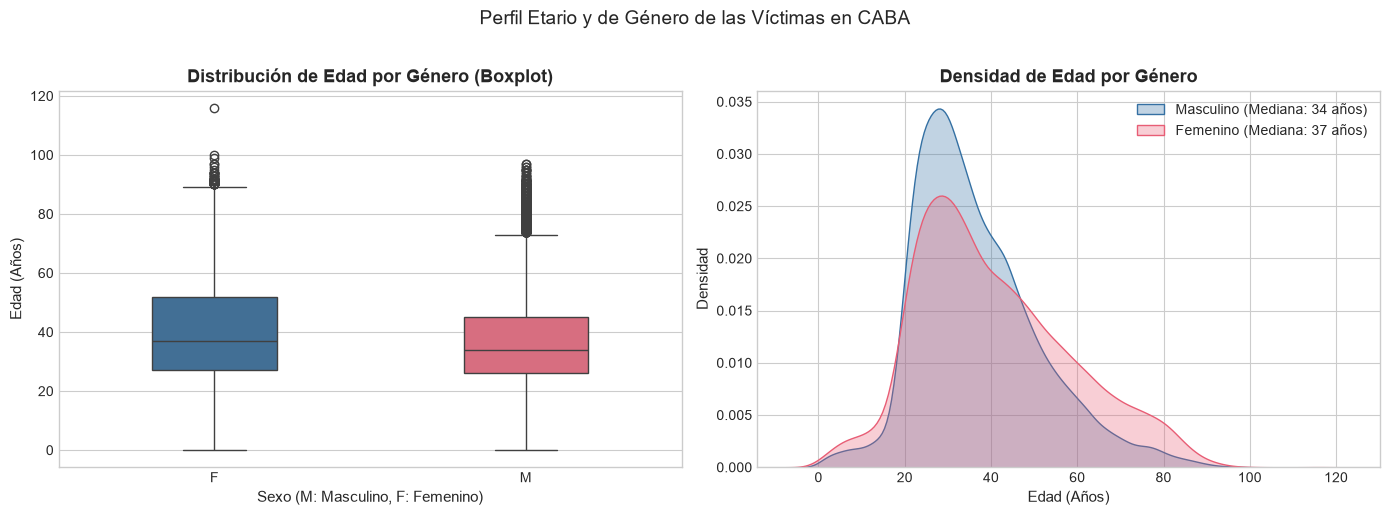

In [ ]:
# 8. Distribución de Edades por Género de la Víctima
victimas_validas = df_victimas.dropna(subset=['edad_victima'])
victimas_validas = victimas_validas[victimas_validas['sexo_victima'].isin(['M', 'F'])]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=victimas_validas, x='sexo_victima', y='edad_victima', palette=['#3470a3', '#e85d75'], ax=ax1, width=0.4)
ax1.set_title('Distribución de Edad por Género (Boxplot)', fontweight='bold')
ax1.set_xlabel('Sexo (M: Masculino, F: Femenino)')
ax1.set_ylabel('Edad (Años)')

# Curvas KDE
mediana_m = victimas_validas[victimas_validas['sexo_victima'] == 'M']['edad_victima'].median()
mediana_f = victimas_validas[victimas_validas['sexo_victima'] == 'F']['edad_victima'].median()

sns.kdeplot(data=victimas_validas[victimas_validas['sexo_victima'] == 'M']['edad_victima'],
            label=f'Masculino (Mediana: {mediana_m:.0f} años)',
            color='#3470a3', fill=True, alpha=0.3, ax=ax2)
sns.kdeplot(data=victimas_validas[victimas_validas['sexo_victima'] == 'F']['edad_victima'],
            label=f'Femenino (Mediana: {mediana_f:.0f} años)',
            color='#e85d75', fill=True, alpha=0.3, ax=ax2)

ax2.set_title('Densidad de Edad por Género', fontweight='bold')
ax2.set_xlabel('Edad (Años)')
ax2.set_ylabel('Densidad')
ax2.legend()

plt.suptitle('Perfil Etario y de Género de las Víctimas en CABA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


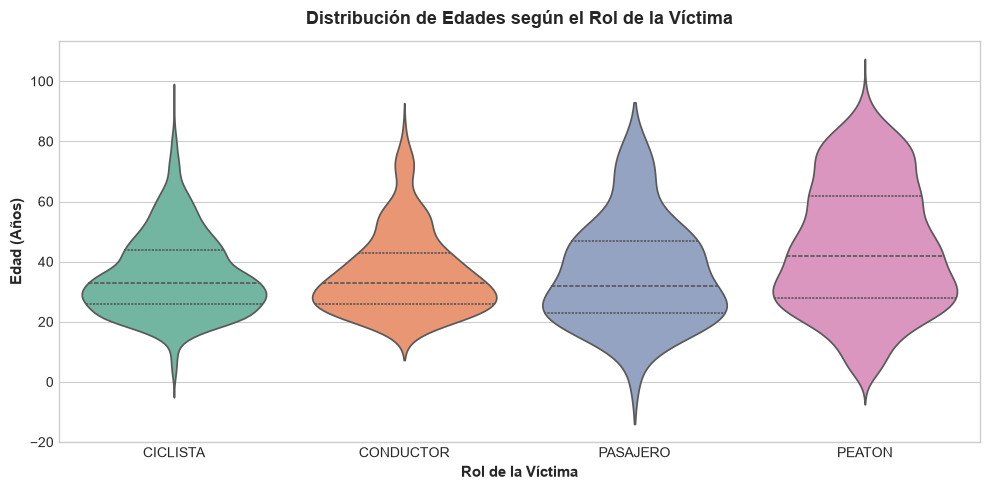

In [ ]:
# 9. Distribución de Edad según el Rol de la Víctima
roles_principales = ['PEATON', 'CICLISTA', 'CONDUCTOR', 'PASAJERO']
victimas_roles = df_victimas[df_victimas['rol_victima'].isin(roles_principales)].dropna(subset=['edad_victima'])

plt.figure(figsize=(10, 5))
sns.violinplot(data=victimas_roles, x='rol_victima', y='edad_victima', palette='Set2', inner='quartile')
plt.title('Distribución de Edades según el Rol de la Víctima', pad=12)
plt.xlabel('Rol de la Víctima', fontweight='bold')
plt.ylabel('Edad (Años)', fontweight='bold')
plt.tight_layout()
plt.show()


**Hallazgo Clave 5 (Demografía y Roles):**
- El **65.8%** de las víctimas identificadas con sexo son **varones**. La concentración máxima de víctimas masculinas se encuentra entre los **20 y 35 años** (pico de repartidores en moto y conductores jóvenes).
- En contraste, el rol de **Peatón** presenta una distribución bimodal con una marcada concentración en **adultos mayores (>60 años)**, quienes poseen menor velocidad de cruce y sufren un impacto de mayor letalidad.


---
### **Bloque 5: Análisis del Target (`gravedad_siniestro`) y Prevención de Data Leakage**


Distribución de la variable objetivo (Target):
                    Cantidad  Porcentaje (%)
gravedad_siniestro                          
LEVE                   62174          94.464
GRAVE                   2955           4.490
MORTAL                   689           1.047


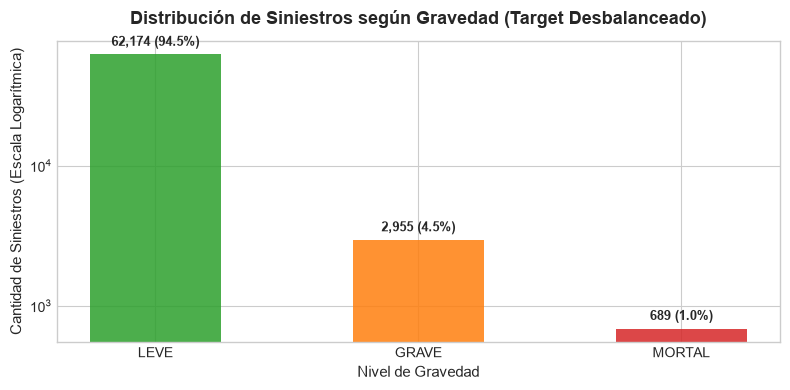

In [ ]:
# 10. Distribución y Desbalance del Target
target_counts = df_analitico['gravedad_siniestro'].value_counts()
target_pct = df_analitico['gravedad_siniestro'].value_counts(normalize=True) * 100

df_target = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct
})

print("Distribución de la variable objetivo (Target):")
print(df_target)

plt.figure(figsize=(8, 4))
colors_target = ['#2ca02c', '#ff7f0e', '#d62728']
bars = plt.bar(df_target.index, df_target['Cantidad'], color=colors_target, alpha=0.85, width=0.5)
plt.title('Distribución de Siniestros según Gravedad (Target Desbalanceado)', pad=12)
plt.xlabel('Nivel de Gravedad')
plt.ylabel('Cantidad de Siniestros (Escala Logarítmica)')
plt.yscale('log') # Escala logarítmica para visualizar las clases minoritarias

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,} ({height/len(df_analitico)*100:.1f}%)',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## **8. Formulación Metodológica para las Próximas Pre-Entregas**

---
### **8.1. Propuesta para la 3ª Pre-Entrega: Modelado Supervisado (Clasificación)**

#### **Definición del Problema:**
Predecir la **gravedad de un siniestro vial** (`LEVE`, `GRAVE`, `MORTAL` o clasificación binaria `GRAVE_O_MORTAL` vs. `LEVE`) a partir de las **condiciones del contexto previo al hecho**.

#### **Decisión Metodológica Crítica: Prevención de DATA LEAKAGE**
En un entorno operativo real, cuando el SAME o la Policía reciben una llamada de emergencia, no se conoce a priori cuántas personas fallecieron en el hospital 20 días después ni el diagnóstico médico final. Por lo tanto:
> **Variables ESTRICTAMENTE EXCLUIDAS del conjunto de features predictoras:**
> - `numero_victimas_mortal_siniestro`
> - `numero_victimas_grave_siniestro`
> - `numero_victimas_leve_siniestro`
> - `fecha_fallecimiento_victima`
> - `gravedad_victima`
>
> *Incluir estas columnas constituiría una fuga de datos directa (data leakage), volviendo al modelo trivial y ficticio.*

#### **Estrategia ante el Fuerte Desbalance de Clases:**
Dado que la clase `LEVE` representa el 94.5% del dataset, un modelo ingenuo que siempre prediga `LEVE` obtendría 94.5% de Accuracy sin predecir jamás una víctima grave o mortal. Implementaremos:
1. **Métricas de Evaluación Adecuadas:** `Macro F1-score`, `Balanced Accuracy`, `Precision-Recall AUC` y `Matriz de Confusión`.
2. **Ponderación de Clases (Cost-Sensitive Learning):** Parámetro `class_weight='balanced'` en los clasificadores.
3. **Técnicas de Balanceo de Muestras:** Comparación con remuestreo sintético (`SMOTE` / `RandomUnderSampler`).
4. **Algoritmos a Evaluar:**
   - **Baseline:** `DummyClassifier` (estrategia mayoritaria).
   - **Modelo Lineal:** `LogisticRegression` regularizada.
   - **Árboles y Ensambles:** `DecisionTreeClassifier`, `RandomForestClassifier`, `HistGradientBoostingClassifier`.

---
### **8.2. Propuesta para la 4ª Pre-Entrega: Aprendizaje No Supervisado (Clustering)**

#### **Objetivo:**
Descubrir **perfiles latentes o arquetipos de siniestros viales** en CABA a partir de variables objetivas espaciotemporales y vehiculares, sin utilizar la etiqueta de gravedad durante el entrenamiento del clustering.

#### **Metodología Propuesta:**
1. **Features para Clustering:**
   - Temporales: `hora_num`, `dia_semana_num`, `es_fin_de_semana`, `es_hora_pico`.
   - Espaciales: `comuna_num`, `tipo_via_normalizado`.
   - Vehiculares: variables binarias (`involucra_moto`, `involucra_peaton`, `involucra_bicicleta`, `involucra_auto`, `involucra_pesado`).
2. **Preprocesamiento:** One-Hot Encoding de variables categóricas + escalado numérico mediante `StandardScaler` / `MinMaxScaler`.
3. **Algoritmos:** `K-Means`, `DBSCAN` (para agrupamiento de densidad espacial) y `Clustering Jerárquico`.
4. **Criterios de Selección de $k$:** Método del Codo (Elbow Method sobre la Inercia) y Coeficiente de Silueta (`Silhouette Score`).
5. **Interpretación y Storytelling de Clusters:**
   - Evaluar *a posteriori* qué tasa de severidad presenta cada cluster descubierto (ej. *Cluster 1: Jóvenes en moto en avenidas durante la noche*, *Cluster 2: Adultos mayores peatones en cruces comerciales diurnos*, *Cluster 3: Colisiones múltiples en autopistas*).


## **9. Conclusiones y Resumen Ejecutivo del AED**

1. **Robustez y Cobertura de los Datos:** Se procesaron con éxito los registros de más de 65.800 siniestros y 75.100 víctimas en CABA (2019-2025), logrando un merge analítico con 100% de integridad referencial.
2. **Impacto Territorial Diferenciado:** Mientras las comunas céntricas (Comuna 1, 3, 15) concentran el mayor volumen bruto de incidentes, las comunas del sur (Comunas 4, 8, 9) sufren una mayor tasa de siniestros graves y letales.
3. **Peligrosidad de Arterias de Alta Velocidad:** Las avenidas acumulan más del 57% de los choques, pero las autopistas y la Av. General Paz multiplican por 3 la tasa de mortalidad por cada 1.000 hechos.
4. **Vulnerabilidad de Motociclistas y Peatones:** Las motos representan el actor más frecuente en colisiones urbanas (principalmente contra automóviles), mientras que los peatones (especialmente adultos mayores) registran la tasa de letalidad individual más severa (2.38%).
5. **Hoja de Ruta Metodológica Consolidada:** Quedan definidas las bases analíticas, el preprocesamiento, el tratamiento del desbalance y las precauciones contra el data leakage para las entregas de Machine Learning supervisado y no supervisado.

---
### **Checklist de la 2ª Pre-Entrega:**
- [x] Tema y datasets elegidos y justificados formalmente.
- [x] Descripción del objetivo y storytelling alineado a políticas de impacto urbano.
- [x] Exploración, diagnóstico de calidad y limpieza de datos con Pandas.
- [x] Transformación y enriquecimiento de datos (Feature Engineering temporal, espacial y vehicular).
- [x] Integración relacional entre tablas de hechos y víctimas.
- [x] Visualizaciones ricas y profesionales univariadas, bivariadas y multivariadas con Seaborn y Matplotlib.
- [x] Planteo fundamentado para las fases de modelado supervisado (pre-entrega 3) y clustering (pre-entrega 4).
